<a href="https://colab.research.google.com/github/mckore/DocsGPT/blob/main/CSE621_2026_Sentiment_Classification_of_Movie_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Classification of Movie Reviews
---
By: Marie-Claire Kore
For: CSE-621
Last Updated: Feb 16, 2026

Import Packages for Notebook 

In [56]:
import polars as pl
import numpy as np
import nltk 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest,  mutual_info_classif, chi2
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.ensemble import VotingClassifier
from nltk.corpus import movie_reviews 
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string
nltk.download('movie_reviews', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('stopwords', quiet=True)
import warnings
warnings.filterwarnings('ignore', module='sklearn')

In [57]:
documents = [(movie_reviews.raw(fileid), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
texts = [doc for doc, label in documents]
labels = [label for doc, label in documents]

In [58]:
def tokenize_basic(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in string.punctuation and t.isalpha()]
    return tokens
texts_basic = [' '.join(tokenize_basic(t)) for t in texts]

In [59]:
sw = set(stopwords.words('english'))
def tokenize_no_stopwords(text):
    tokens = tokenize_basic(text)
    return [t for t in tokens if t not in sw]
texts_no_stop = [' '.join(tokenize_no_stopwords(t)) for t in texts]

In [60]:
stemmer = PorterStemmer()
def tokenize_stemmed(text):
    tokens = tokenize_no_stopwords(text)
    return [stemmer.stem(t) for t in tokens]
texts_stemmed = [' '.join(tokenize_stemmed(t)) for t in texts]

In [61]:
lemmatizer = WordNetLemmatizer()
def tokenize_lemmatized(text):
    tokens = tokenize_no_stopwords(text)
    return [lemmatizer.lemmatize(t,  pos='v') for t in tokens]
texts_lemmatized = [' '.join(tokenize_lemmatized(t)) for t in texts]

In [62]:
vectorizer = TfidfVectorizer(max_features=5000)
x_basic = vectorizer.fit_transform(texts_basic)
x_no_stop = TfidfVectorizer(max_features=5000).fit_transform(texts_no_stop)
x_stemmed = TfidfVectorizer(max_features=5000).fit_transform(texts_stemmed)
x_lemmatized = TfidfVectorizer(max_features=5000).fit_transform(texts_lemmatized)

In [63]:
from sklearn.model_selection import cross_validate

def evaluate_pipeline(X, y, model):
    scores = cross_validate(model, X, y, scoring=['f1', 'accuracy'], cv=5)
    print(f"{model} results - f1: {scores['test_f1'].mean():.3f} 'accuracy': {scores['test_accuracy'].mean():.3f}")
    return {
        'f1_mean': scores['test_f1'].mean(),
        'accuracy_mean': scores['test_accuracy'].mean(),
        'f1_std': scores['test_f1'].std(),
    }

In [64]:
preprocessing_results = []
clf = LogisticRegression(C=1.0, max_iter=1000)
preprocessing_data = {
    'basic': x_basic,
    'no_stopwords': x_no_stop,
    'stemmed': x_stemmed,
    'lemmatized': x_lemmatized
}
y = np.array([1 if label == 'pos' else 0 for label in labels])
for name, x in preprocessing_data.items():
    metrics = evaluate_pipeline(x, y, clf)
    preprocessing_results.append({'preprocessing': name, **metrics})
preprocessing_df = pl.DataFrame(preprocessing_results)

LogisticRegression(max_iter=1000) results - f1: 0.826 'accuracy': 0.826
LogisticRegression(max_iter=1000) results - f1: 0.847 'accuracy': 0.844
LogisticRegression(max_iter=1000) results - f1: 0.837 'accuracy': 0.836
LogisticRegression(max_iter=1000) results - f1: 0.844 'accuracy': 0.842


In [65]:
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
base = vectorizer.fit_transform(texts)
chi2_selkbest = SelectKBest(chi2, k=2000)
x_chi2 = chi2_selkbest.fit_transform(base, y)
mi_selkbest = SelectKBest( mutual_info_classif, k=2000)
x_mi = mi_selkbest.fit_transform(base, y)

In [66]:
configs = {
'NB_Multinomial': MultinomialNB(),
'MultiNB_a0.5': MultinomialNB(alpha=0.5),
'MultiNB_a0.1': MultinomialNB(alpha=0.1),
'NB_Bernoulli': BernoulliNB(),
'LR_C0.1': LogisticRegression(C=0.1, max_iter=1000),
'LR1': LogisticRegression(C=1.0, max_iter=1000),
'LR_C10': LogisticRegression(C=10.0, max_iter=1000),
'LR_L1': LogisticRegression(C=1.0, penalty='l1', solver='saga',max_iter=1000),
'SVM_linear_C0.1': LinearSVC(C=0.1, max_iter=2000),
'SVM_linear_C1.0': LinearSVC(C=1.0, max_iter=2000),
'SVM_linear_C10': LinearSVC(C=10.0, max_iter=2000),
}

In [67]:
vec_configs = {
'tf_ugram': CountVectorizer(max_features=5000, ngram_range=(1,1)),
'tf_bigram': CountVectorizer(max_features=5000, ngram_range=(1,2)),
'tfidf_ugram': TfidfVectorizer(max_features=5000, ngram_range=(1,1)),
'tfidf_bigram': TfidfVectorizer(max_features=5000, ngram_range=(1,2))
}
vec_results = []
for vec_name, vectorizer in vec_configs.items():
    x = vectorizer.fit_transform(texts_stemmed)
    clf = LogisticRegression(C=1.0, max_iter=1000)
    metrics = evaluate_pipeline(x, y, clf)
    result = {'vectorizer': vec_name, 'n_features': x.shape[1], **metrics}
    vec_results.append(result)
vec_df = pl.DataFrame(vec_results)

LogisticRegression(max_iter=1000) results - f1: 0.823 'accuracy': 0.823
LogisticRegression(max_iter=1000) results - f1: 0.829 'accuracy': 0.830
LogisticRegression(max_iter=1000) results - f1: 0.837 'accuracy': 0.836
LogisticRegression(max_iter=1000) results - f1: 0.839 'accuracy': 0.837


In [68]:
base_vec= TfidfVectorizer(max_features=10000)
x_exp3_base = base_vec.fit_transform(texts_stemmed)
fs_methods = {
    'base': None,
    'mi_1000': SelectKBest(mutual_info_classif, k=1000),
    'mi_2000': SelectKBest(mutual_info_classif, k=2000),
    'mi_5000': SelectKBest(mutual_info_classif, k=5000),
    'chi2_1000': SelectKBest(chi2, k=1000),
    'chi2_2000': SelectKBest(chi2, k=2000),
    'chi2_5000': SelectKBest(chi2, k=5000),
}
feature_selection_results = []
for fs_name, selector in fs_methods.items():
    if selector is None:
        x_selected = x_exp3_base
    else:
        x_selected = selector.fit_transform(x_exp3_base, y)
    clf = LogisticRegression(C=1.0, max_iter=1000)
    metrics = evaluate_pipeline(x_selected, y, clf)
    result = {'feature_selection': fs_name, 'n_features': x_selected.shape[1], **metrics}
    feature_selection_results.append(result)

LogisticRegression(max_iter=1000) results - f1: 0.832 'accuracy': 0.830
LogisticRegression(max_iter=1000) results - f1: 0.815 'accuracy': 0.810
LogisticRegression(max_iter=1000) results - f1: 0.830 'accuracy': 0.829
LogisticRegression(max_iter=1000) results - f1: 0.832 'accuracy': 0.830
LogisticRegression(max_iter=1000) results - f1: 0.870 'accuracy': 0.867
LogisticRegression(max_iter=1000) results - f1: 0.877 'accuracy': 0.875
LogisticRegression(max_iter=1000) results - f1: 0.870 'accuracy': 0.868


In [69]:
exp4_vectorizer = TfidfVectorizer(max_features=5000)
x_exp4_base = exp4_vectorizer.fit_transform(texts_stemmed)
exp4_selector = SelectKBest(mutual_info_classif, k=2000)
x_selected = exp4_selector.fit_transform(x_exp4_base, y)
exp4_classifiers = {
    'NB_Multinomial': MultinomialNB(),
    'NB_Multinomial_a0.5': MultinomialNB(alpha=0.5),
    'NB_Multinomial_a0.1': MultinomialNB(alpha=0.1),
    'NB_Bernoulli': BernoulliNB(),
    'LR_C0.1': LogisticRegression(C=0.1, max_iter=1000),
    'LR_C1.0': LogisticRegression(C=1.0, max_iter=1000),
    'LR_C10': LogisticRegression(C=10.0, max_iter=1000),
    'LR_L1': LogisticRegression(penalty='l1', solver='saga', max_iter=1000),
    'SVM_linear_C0.1': LinearSVC(C=0.1, max_iter=2000),
    'SVM_linear_C1.0': LinearSVC(C=1.0, max_iter=2000),
    'SVM_linear_C10': LinearSVC(C=10.0, max_iter=2000)
}
classifier_results = []
for clf_name, clf in exp4_classifiers.items():
    metrics = evaluate_pipeline(x_selected, y, clf)
    if 'NB' in clf_name:
        model_type = 'Naive Bayes'
    elif 'LR' in clf_name:
        model_type = 'Logistic Regression'
    else:
        model_type = 'SVM'
    result = {'classifier': clf_name, 'model_type': model_type, **metrics}
    classifier_results.append(result)
classifier_df = pl.DataFrame(classifier_results)

MultinomialNB() results - f1: 0.806 'accuracy': 0.808
MultinomialNB(alpha=0.5) results - f1: 0.809 'accuracy': 0.810
MultinomialNB(alpha=0.1) results - f1: 0.811 'accuracy': 0.811
BernoulliNB() results - f1: 0.769 'accuracy': 0.782
LogisticRegression(C=0.1, max_iter=1000) results - f1: 0.807 'accuracy': 0.805
LogisticRegression(max_iter=1000) results - f1: 0.831 'accuracy': 0.830
LogisticRegression(C=10.0, max_iter=1000) results - f1: 0.839 'accuracy': 0.838
LogisticRegression(max_iter=1000, penalty='l1', solver='saga') results - f1: 0.785 'accuracy': 0.771
LinearSVC(C=0.1, max_iter=2000) results - f1: 0.830 'accuracy': 0.829
LinearSVC(max_iter=2000) results - f1: 0.840 'accuracy': 0.838
LinearSVC(C=10.0, max_iter=2000) results - f1: 0.821 'accuracy': 0.818


In [70]:
optimized_voting = VotingClassifier(
    estimators=[
        ('nb', MultinomialNB(alpha=0.5)),
        ('lr1', LogisticRegression(C=1.0, max_iter=1000)),
        ('lr2', LogisticRegression(C=0.1, max_iter=1000)),
        ('svm', LinearSVC(C=1.0, max_iter=2000))
    ],
    voting='hard'
)
ensemble_results = []
metrics = evaluate_pipeline(x_selected, y, optimized_voting)
ensemble_results.append({'ensemble': 'Optimized_Voting', **metrics})
ensemb_df = pl.DataFrame(ensemble_results)

VotingClassifier(estimators=[('nb', MultinomialNB(alpha=0.5)),
                             ('lr1', LogisticRegression(max_iter=1000)),
                             ('lr2', LogisticRegression(C=0.1, max_iter=1000)),
                             ('svm', LinearSVC(max_iter=2000))]) results - f1: 0.821 'accuracy': 0.823


In [71]:
indv_idx = classifier_df['f1_mean'].arg_max()
indv = classifier_df.row(indv_idx, named=True)
ensemb_idx = ensemb_df['f1_mean'].arg_max()
ensemb = ensemb_df.row(ensemb_idx, named=True)
print(f"Best Individual Model: {indv['classifier']}")
print(f"f1 score {indv['f1_mean']:.3f} accuracy {ensemb['accuracy_mean']:.3f}")
print(f"Best Ensemble Model: {ensemb['ensemble']}")
print(f"f1 score {ensemb['f1_mean']:.3f} accuracy {ensemb['accuracy_mean']:.3f}")
improvement = ensemb['f1_mean'] - indv['f1_mean']
if improvement > 0:
    print("Ensemble BEATS the best individual model!")
else:
    print("Ensemble does not beat the best individual model.")

Best Individual Model: SVM_linear_C1.0
f1 score 0.840 accuracy 0.823
Best Ensemble Model: Optimized_Voting
f1 score 0.821 accuracy 0.823
Ensemble does not beat the best individual model.


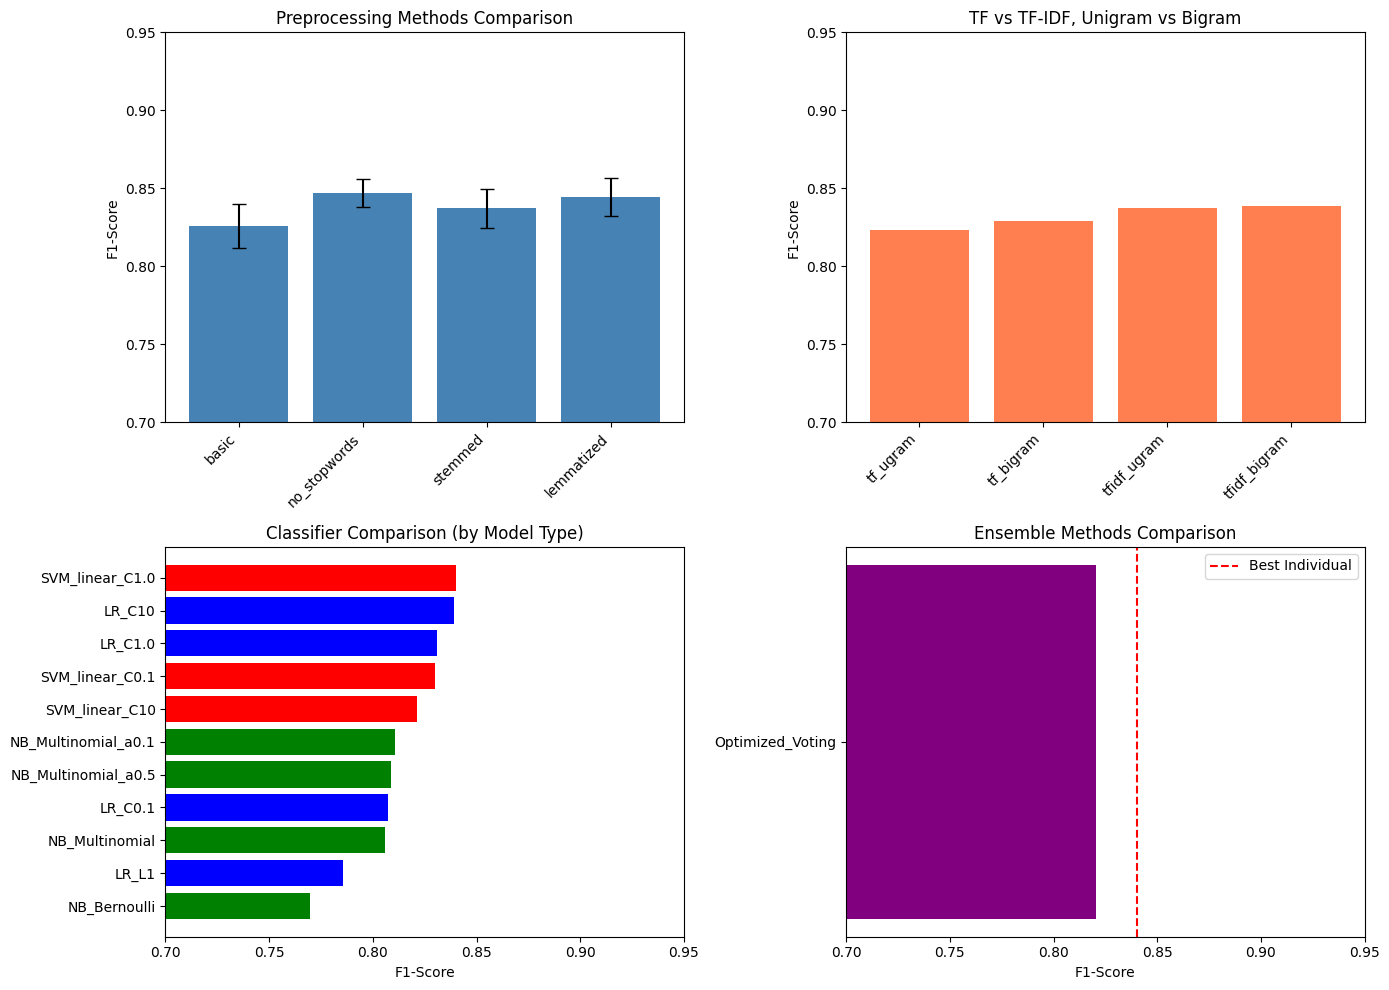

In [72]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
x = range(len(preprocessing_df))
ax1.bar(x, preprocessing_df['f1_mean'], yerr=preprocessing_df['f1_std'], capsize=5, color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(preprocessing_df['preprocessing'], rotation=45, ha='right')
ax1.set_ylabel('F1-Score')
ax1.set_title('Preprocessing Methods Comparison')
ax1.set_ylim(0.7, 0.95)

ax2 = axes[0, 1]
x = range(len(vec_df))
ax2.bar(x, vec_df['f1_mean'], color='coral')
ax2.set_xticks(x)
ax2.set_xticklabels(vec_df['vectorizer'], rotation=45, ha='right')
ax2.set_ylabel('F1-Score')
ax2.set_title('TF vs TF-IDF, Unigram vs Bigram')
ax2.set_ylim(0.7, 0.95)

ax3 = axes[1, 0]
sorted_clf = classifier_df.sort('f1_mean')
colors = {'Naive Bayes': 'green', 'Logistic Regression': 'blue', 'SVM': 'red'}
bar_colors = [colors[mt] for mt in sorted_clf['model_type']]
ax3.barh(range(len(sorted_clf)), sorted_clf['f1_mean'], color=bar_colors)
ax3.set_yticks(range(len(sorted_clf)))
ax3.set_yticklabels(sorted_clf['classifier'])
ax3.set_xlabel('F1-Score')
ax3.set_title('Classifier Comparison (by Model Type)')
ax3.set_xlim(0.7, 0.95)

ax4 = axes[1, 1]
sorted_ens = ensemb_df.sort('f1_mean')
ax4.barh(range(len(sorted_ens)), sorted_ens['f1_mean'], color='purple')
ax4.set_yticks(range(len(sorted_ens)))
ax4.set_yticklabels(sorted_ens['ensemble'])
ax4.set_xlabel('F1-Score')
ax4.set_title('Ensemble Methods Comparison')
ax4.axvline(x=indv['f1_mean'], color='red', linestyle='--', label='Best Individual')
ax4.legend()
ax4.set_xlim(0.7, 0.95)

plt.tight_layout()
plt.savefig('results_visualization.png', dpi=150, bbox_inches='tight')
plt.show()